In [1]:
import pandas as pd
import os

In [2]:
items = os.listdir()

In [3]:
import os
import json

def get_data(item_path, item, file_name):
    json_path = os.path.join(item_path, file_name)
    if os.path.exists(json_path):
        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                return json.load(f)
            print(f"Loaded report from: {item}")
        except Exception as e:
            print(f"Error loading {item}/report.json: {e}")
    else:
        print(f"!! No report.json found in: {item}")

current_dir = os.getcwd()
data_reports = {}
data_config = {}
report_names = []
data_full = {}
# what to extract
term = 'pde'
# Get all items in current directory
for item in os.listdir(current_dir):
    item_path = os.path.join(current_dir, item)
    if os.path.isdir(item_path):
        # config
        data_full[item] = {}
        print(item_path)
        data = get_data(item_path, item, 'model_metadata.json')['args']
        data_config[item] = {
            "lambda_ic": data["lambda_ic"],
            "dataset": data["description"],
        }
        data_full[item]["lambda_ic"] = data["lambda_ic"]
        data_full[item]["dataset"] = data["description"]
        # report
        data = get_data(item_path, item, 'report.json')
        data_reports[item] = {
            "linf": data["test_linf"][term],
            "rel_l2": data["test_rel_l2"][term],
        }
        data_full[item]["linf"] = data["test_linf"][term]
        data_full[item]["rel_l2"] = data["test_rel_l2"][term]
        report_names.append(item)

print(f"\nTotal reports loaded: {len(report_names)}")

/home/antos_j/diploma_sketchbook/PINN/case0_HeatEq/gridsearch__2026-07-07--12-36-01/lambda_ic=0p1__description=full-batch_fixed__n_res_points=4096__bs=4096__one_batch_per_epoch=True__prevent_resampling=True
/home/antos_j/diploma_sketchbook/PINN/case0_HeatEq/gridsearch__2026-07-07--12-36-01/lambda_ic=0p1__description=mini-batch_fixed__n_res_points=4096__bs=512__one_batch_per_epoch=False__prevent_resampling=True
/home/antos_j/diploma_sketchbook/PINN/case0_HeatEq/gridsearch__2026-07-07--12-36-01/lambda_ic=0p1__description=full-batch_resampl__n_res_points=4096__bs=4096__one_batch_per_epoch=True__prevent_resampling=False__resampling_frequency=1
/home/antos_j/diploma_sketchbook/PINN/case0_HeatEq/gridsearch__2026-07-07--12-36-01/lambda_ic=0p1__description=mini-batch_resampl__n_res_points=4096__bs=512__one_batch_per_epoch=False__prevent_resampling=False__resampling_frequency=1
/home/antos_j/diploma_sketchbook/PINN/case0_HeatEq/gridsearch__2026-07-07--12-36-01/lambda_ic=1p0__description=full-ba

In [4]:
data_full

{'lambda_ic=0p1__description=full-batch_fixed__n_res_points=4096__bs=4096__one_batch_per_epoch=True__prevent_resampling=True': {'lambda_ic': 0.1,
  'dataset': 'full-batch,fixed',
  'linf': 0.06675870716571808,
  'rel_l2': 0.03974237923106335},
 'lambda_ic=0p1__description=mini-batch_fixed__n_res_points=4096__bs=512__one_batch_per_epoch=False__prevent_resampling=True': {'lambda_ic': 0.1,
  'dataset': 'mini-batch,fixed',
  'linf': 0.025199174880981445,
  'rel_l2': 0.011419496819796735},
 'lambda_ic=0p1__description=full-batch_resampl__n_res_points=4096__bs=4096__one_batch_per_epoch=True__prevent_resampling=False__resampling_frequency=1': {'lambda_ic': 0.1,
  'dataset': 'full-batch,resampl',
  'linf': 0.07163171470165253,
  'rel_l2': 0.04343815325857262},
 'lambda_ic=0p1__description=mini-batch_resampl__n_res_points=4096__bs=512__one_batch_per_epoch=False__prevent_resampling=False__resampling_frequency=1': {'lambda_ic': 0.1,
  'dataset': 'mini-batch,resampl',
  'linf': 0.01786339282989502

In [5]:
list(data_full.values())

[{'lambda_ic': 0.1,
  'dataset': 'full-batch,fixed',
  'linf': 0.06675870716571808,
  'rel_l2': 0.03974237923106335},
 {'lambda_ic': 0.1,
  'dataset': 'mini-batch,fixed',
  'linf': 0.025199174880981445,
  'rel_l2': 0.011419496819796735},
 {'lambda_ic': 0.1,
  'dataset': 'full-batch,resampl',
  'linf': 0.07163171470165253,
  'rel_l2': 0.04343815325857262},
 {'lambda_ic': 0.1,
  'dataset': 'mini-batch,resampl',
  'linf': 0.01786339282989502,
  'rel_l2': 0.01238520840986258},
 {'lambda_ic': 1.0,
  'dataset': 'full-batch,fixed',
  'linf': 0.05959880352020264,
  'rel_l2': 0.040945697945738734},
 {'lambda_ic': 1.0,
  'dataset': 'mini-batch,fixed',
  'linf': 0.0262526273727417,
  'rel_l2': 0.018854714516147474},
 {'lambda_ic': 1.0,
  'dataset': 'full-batch,resampl',
  'linf': 0.061901867389678955,
  'rel_l2': 0.041556836243057144},
 {'lambda_ic': 1.0,
  'dataset': 'mini-batch,resampl',
  'linf': 0.013176321983337402,
  'rel_l2': 0.009988057851039182},
 {'lambda_ic': 10.0,
  'dataset': 'full-b

In [6]:
# Create DataFrame
def create_pivot_table(err_type):
    df = pd.DataFrame(list(data_full.values()))

    pivot = df.pivot_table(
        index='lambda_ic',
        columns='dataset',
        values=err_type,
        aggfunc='first' # in case of duplicates
    )
    pivot = pivot.sort_index().sort_index(axis=1)

    #print("=== L2 Grid Search Results ===")
    #print(pivot.round(6))
    return pivot



In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_matrix(pivot, err_type, cmap):
    data = pivot.to_numpy()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(data, cmap=cmap)
    
    # Labels
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
    ax.set_yticklabels(pivot.index)
    
    ax.set_title('Grid Search')
    ax.set_xlabel('bs')
    ax.set_ylabel('lambda_ic')
    
    # Annotate values
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not np.isnan(data[i,j]):
                ax.text(j, i, f'{data[i,j]:.4f}', ha='center', va='center', color='black')
    
    plt.colorbar(im, label=err_type)
    plt.tight_layout()
    plt.show()


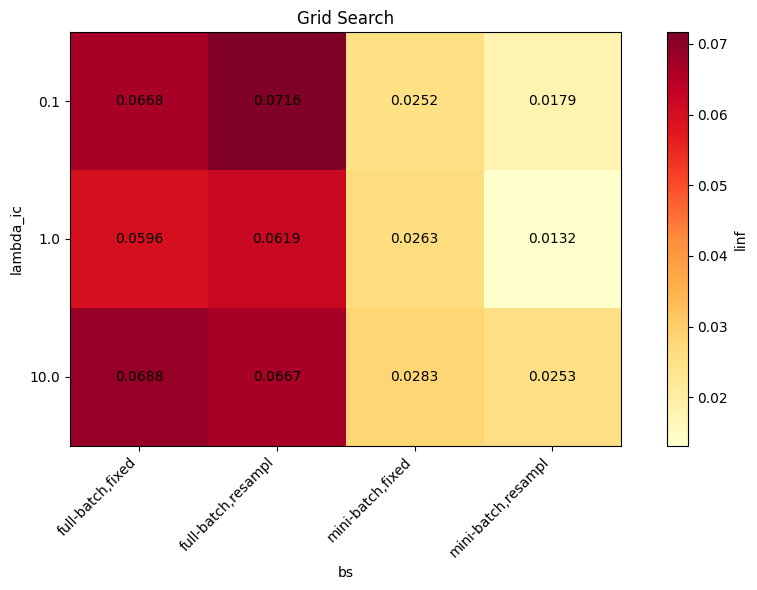

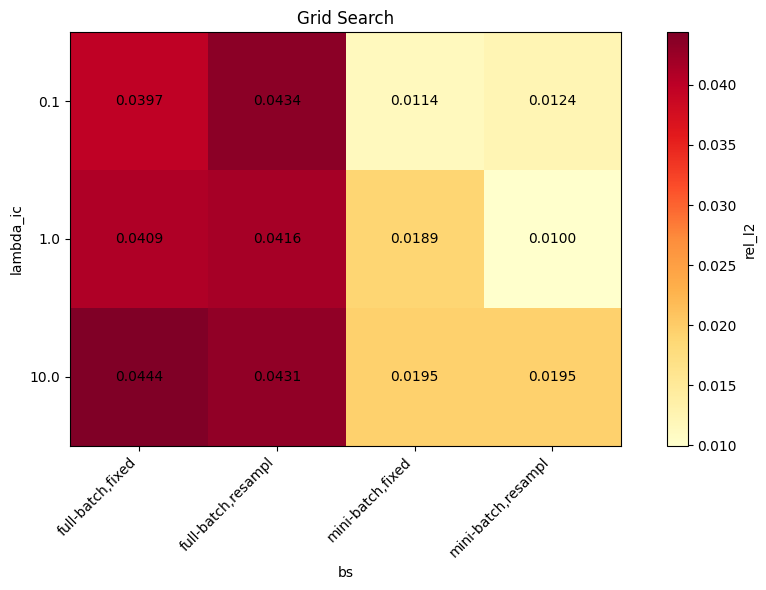

In [8]:
err_type = 'linf'
pivot = create_pivot_table(err_type)
plot_matrix(pivot, err_type, cmap='YlOrRd')
err_type = 'rel_l2'
pivot = create_pivot_table(err_type)
plot_matrix(pivot, err_type, cmap='YlOrRd')